# **Кластерный анализ. Описание набора данных.**

Представлен набор искусственных данных о **990 ноутбуках** различных производителей с разными характеристиками. Анализ проводится для ноутбуков с процессорами **AMD RYZEN** и дискретными видеокартами **NVIDIA**.

**Переменные датасета:**

**1. Brand**
- производитель ноутбука (MSI, Acer, ASUS, Dell, HP).

**2. Name**
- полное название модели ноутбука (например, Acer Swift 2024).

**3. CPU**
- модель установденного процессора AMD Ryzen в ноутбуке (например, Ryzen 3, Ryzen 5, Ryzen 7, Ryzen 9).

**4. cpu_cores**
- количество физических ядер процессора
    - Ryzen 3 - 4 ядра
    - Ryzen 5 - 6 ядер
    - Ryzen 7 - 8 ядер
    - Ryzen 9 - 12 ядер

**5. cpu_turbo_GHz**
- максимальня частота процессова в турбобусте в гигагерцах (рассматриваем именно игровые ноутбуки, поэтому не трогаем базовые частоты работы процессора).

**6. GPU**
- модель установленной дискретной видеокарты NVIDIA (например, GTX 1650, RTX 3050, RTX 4070, RTX 4090).

**7. gpu_power_W**
- потребляемая можность GPU (или по-другому TGP) в ваттах, отражает фактический уровень производительности видеокарты.
К примеру,
    - GTX 1650 - 50 W
    - RTX 3060 - 80 W
    - RTX 4070 - 115 W
    - RTX 4090 - 175 W,
    но могут быть и, казалось бы, "сильные" видеокарты, но с низкой мощностью.

**8. RAM (GB)**
- объём оперативной памяти в гигабайтах.
Зависит от установленного процессора:
    - Ryzen 3 - 8-16 GB
    - Ryzen 5 - 16 GB
    - Ryzen 7/9 - 16-32 GB
В целом, имеются конфигурации с 8, 16, 24 и 32 гигабайтами RAM.

**9. SSD (GB)**
- объём SSD-накопителя
Зависит от установленного процессора:
    - Ryzen 3 - 256-512 GB
    - Ryzen 5 - 256-1024 GB
    - Ryzen 7 - 512-1024 GB
    - Ryzen 9 - 512-2048 GB

**10. Price_RUB**
- цена ноутбука в рублях, округлённая до сотен.
Зависит от CPU, GPU, RAM и SSD.

# **Предварительный анализ данных**

Выберем библиотеки и методы, которыми будем пользоваться для выполнения работы по анализу данных

In [ ]:
import pandas as pd
import numpy as np

from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Загружаем свой датасет из GitHub

In [ ]:
url = "https://raw.githubusercontent.com/Oplot/laptop-amd-nvidia-dataset/main/laptop_database.csv"

Создадим переменную df, отвечающую за таблицу

In [ ]:
df = pd.read_csv(url)

Смотрим на данные через print(df) (можно использовать просто df, df.head(), df.tail())

In [ ]:
print(df)

      id   Brand                Name      CPU  cpu_cores  cpu_turbo_GHz  \
0      1     MSI     Dell Strix 2024  Ryzen 7          8            4.2   
1      2  Lenovo  Lenovo Legion 2023  Ryzen 9         12            4.5   
2      3    Dell        MSI Max 2020  Ryzen 5          6            4.0   
3      4  Lenovo           HP X 2019  Ryzen 3          4            3.7   
4      5      HP          MSI X 2020  Ryzen 9         12            4.5   
..   ...     ...                 ...      ...        ...            ...   
985  986    Dell   Acer IdeaPad 2019  Ryzen 5          6            4.0   
986  987  Lenovo   Lenovo Strix 2022  Ryzen 5          6            4.0   
987  988    ASUS     HP IdeaPad 2024  Ryzen 5          6            4.0   
988  989  Lenovo  Lenovo Gaming 2023  Ryzen 7          8            4.2   
989  990  Lenovo       Dell Neo 2023  Ryzen 3          4            3.7   

                 GPU  gpu_power_W  RAM_GB  SSD_GB  Price_RUB  
0    NVIDIA RTX 3070          115   

Затем выполним проверку на пропущенные значения в данных. Это возможно осуществить с помощью df.info()

In [ ]:
df.info() #просмотр количества наблюдений и типы данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             990 non-null    int64  
 1   Brand          990 non-null    object 
 2   Name           990 non-null    object 
 3   CPU            990 non-null    object 
 4   cpu_cores      990 non-null    int64  
 5   cpu_turbo_GHz  990 non-null    float64
 6   GPU            990 non-null    object 
 7   gpu_power_W    990 non-null    int64  
 8   RAM_GB         990 non-null    int64  
 9   SSD_GB         990 non-null    int64  
 10  Price_RUB      990 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 85.2+ KB


В моём случае нет пропущенных значений, так как поличество наблюдений в каждом столбце одинаково. Все строки заполнены. Можем, на всякий случай, убедиться в этом ещё раз с помощью кода.

In [ ]:
#удаление пропущенных значений
df = df.dropna().reset_index(drop=True) #reset_index(drop=True) нужно для обновления индексации
df.drop('ID', axis=1, inplace=True) #удаление ВНЕ копии через inplace=True

Далее посмотрим сделаем проверку на **полностью** дублирующие друг друга строки.
Запустим код ниже и посмотрим, есть ли в моём датасете дубликаты.

In [ ]:
duplicates = df.duplicated() #провека на наличие дубликатов
duplicate_indexes = duplicates[duplicates].index.tolist() #выводит индексы, которые можно передать в .drop
duplicate_indexes

[]

Выводится пустой список, а это значит, что в таблице нет дубликатов. Да, могут быть одинаковые процессоры, одинаковые видеокарты, но при этом может разный объём ОЗУ или SSD.

На всякий случай, укажу, что вывести дюбликаты можно с помощью следующего кода (вывести, но не удалить!)

In [ ]:
#Вывод индексов ВСЕХ ДУБЛИКАТОВ, не для удаления, а для просмотра
# all_duplicates = df.duplicated(keep = False) #проверка на наличие дубликатов
# all_duplicate_indexes = all_duplicates[all_duplicates].index.tolist() #выводит индексы, которые можно передать в .drop() для удаления, оставляя 1 уникальное значение в датафрейме
# all_duplicate_indexes

А удаление дубликатов, если бы они были, можно былло бы реализовать с помощью следующего кода.

In [ ]:
#Удаляем строки с дублирующими индексами
df = df.drop(duplicate_indexes).reset_index(drop=True) #присваеваем напрямую исходному датафрейму
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             990 non-null    int64  
 1   Brand          990 non-null    object 
 2   Name           990 non-null    object 
 3   CPU            990 non-null    object 
 4   cpu_cores      990 non-null    int64  
 5   cpu_turbo_GHz  990 non-null    float64
 6   GPU            990 non-null    object 
 7   gpu_power_W    990 non-null    int64  
 8   RAM_GB         990 non-null    int64  
 9   SSD_GB         990 non-null    int64  
 10  Price_RUB      990 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 85.2+ KB


Ничего не удалено. А это подтверждает слова о том, что в таблице изначально всё было чисто - без дубликатов.

Далее проверим, есть ли у меня соблцы с одним уникальным значением.

In [ ]:
df.nunique()

,0
id,990
Brand,6
Name,388
CPU,4
cpu_cores,4
cpu_turbo_GHz,4
GPU,12
gpu_power_W,9
RAM_GB,4
SSD_GB,4


У меня 0 столбцов, где встречается лишь 1 уникальное значение, значит, ничего не нужно удалять.
У меня 6 брендов ноутбуков, 388 полных их имён, 4 типа процессоров, 4 типа количества ядер и т.д.

Следующий шаг - проверим уникальные значения в категориальных столбцах

In [ ]:
for col in df.columns:
  print(col, df[col].unique())

id [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246

При выводе значений видим нормальные и разнообразные данные:
    CPU - Ryzen 3, 5, 7, 9
    GPU - GTX 1650, RTX 2050, 3070, 4090 и т.д.
Никаких пустых категорий нет.

Перейдём к поиску и удалёнию столбцов, препятствующих кластеризации.
Нам могут помешать id, Brand, Name, CPU, GPU.


In [ ]:
df = df.drop(['id', 'Brand', 'Name', 'CPU', 'GPU'], axis=1)
print(df)

     cpu_cores  cpu_turbo_GHz  gpu_power_W  RAM_GB  SSD_GB  Price_RUB
0            8            4.2          115      24    1024     162000
1           12            4.5          175      24    1024     282000
2            6            4.0           85      16     512     105000
3            4            3.7           65       8     256      50000
4           12            4.5          115      16     512     200000
..         ...            ...          ...     ...     ...        ...
985          6            4.0          115      16     512     110000
986          6            4.0           85      16     512     105000
987          6            4.0           85      16     512     105000
988          8            4.2          150      32    1024     207000
989          4            3.7           50       8     512      50000

[990 rows x 6 columns]


Теперь остались только числовые признаки:
1. cpu_cores
2. cpu_turbo_GHz
3. gpu_power_W
4. RAM_GB
5. SSD_GB
6. Price_RUB
Их можно кластеризовать.

Далее посмотрим на описательную статистику, чтобы проверить наличие или отсутствие "странных" значений

In [ ]:
df.describe().round(2)

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
count,990.00,990.00,990.00,990.00,990.00,990.00
mean,7.50,4.10,102.77,18.77,734.90,143228.28
std,2.96,0.29,43.86,7.25,475.32,75687.24
min,4.00,3.70,50.00,8.00,256.00,45000.00
25%,4.00,3.70,65.00,16.00,512.00,60000.00
50%,8.00,4.20,85.00,16.00,512.00,128500.00
75%,8.00,4.20,150.00,24.00,1024.00,212000.00
max,12.00,4.50,180.00,32.00,2048.00,300000.00


По описательному анализу видно следующее:
1. Среднее количество ядер (cpu_cores) = 7.5 (min 4, max 12).
2. Средняя частота процессора в режиме турбобуста (cpu_turbo_GHz) = 4.1 ГГц (min 3.7, max 4.5).
3. Средняя мощность GPU (gpu_power_W) = 102.77 Вт.
4. Средний объём ОЗУ (RAM_GB) = 18.77 Гб.
5. Средний объём SSD (SSD_GB) = 734.9 Гб.
6. Средняя цена ноутбука (Price_RUB) составила 143228.28 рублей.

Все значения находятся в пределах реальных характеристик для ноутбуков, "странных" аномалий не было обнаружено.

# Разведочный анализ

Целью разведочного анализа является проведение статистического анализа данных (выявление взаимосвязи, определение типа распределения данных) и осуществление анализа выбросов.

Оставляем только числовые столбцы.

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

Далее строим корреляционную матрицу.

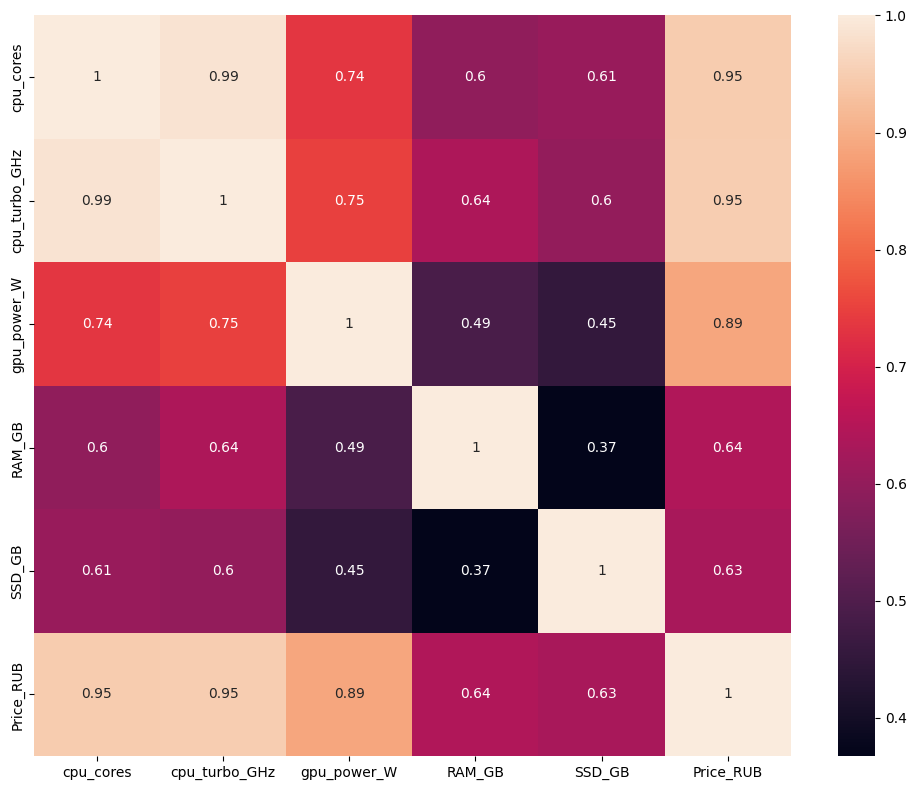

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(numeric_df.corr(), annot=True)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


Цена сильнее всего коррелирует с pgu_power_W, cpu_cores, RAM_GB.
Для игровых ноутбуков это классика: GPU определяет львиную долю конечной цены ноутбука.

Видно корреляцию CPU и GPU.
Мощные видеокарты чаще всего встречаются в моделях с большим числом ядер (у Ryzen 7 и Ryzen 9). Частота CPU в турбобусте (cpu_turbo_GHz) умеренно коррелирует и с ценой (Price_RUB), и с мощностью GPU (gpu_power_W).

SSD слабо влияет на цену
В игровых моделях SSD - не является основным фактором цены (важнее графика и процессор).

Также корреляции можно выводить  с помощью обычной таблицы.

In [ ]:
df.corr().round(3)

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
cpu_cores,1.000,0.986,0.735,0.596,0.607,0.947
cpu_turbo_GHz,0.986,1.000,0.748,0.638,0.601,0.949
gpu_power_W,0.735,0.748,1.000,0.491,0.453,0.889
RAM_GB,0.596,0.638,0.491,1.000,0.367,0.643
SSD_GB,0.607,0.601,0.453,0.367,1.000,0.630
Price_RUB,0.947,0.949,0.889,0.643,0.630,1.000


Перейдём к анализу квантильных групп.

Если в .describe() приводятся стандартные квантили, то .quantile() даёт возможность анализировать детальнее и представлять иные квартильные значения

In [ ]:
df.quantile([0.1, 0.9]).round(2) #квантили

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
0.1,4.0,3.7,50.0,8.0,256.0,50000.0
0.9,12.0,4.5,175.0,32.0,1024.0,255000.0


Отсюда выходит, что 10% самых слабых ноутбуков имеют характеристики:
    - cpu_cores = 4
    - cpu_turbo_GHz = 3.7
    - gpu_power_W = 50
    - RAM_GB = 8
    - SSD_GB = 256
    - Price_RUB = 50000
При этом, 10% самых мощных имеют следующее:
    - cpu_cores = 12
    - cpu_turbo_GHz = 4.5
    - gpu_power_W = 175
    - RAM_GB = 32
    - SSD_GB = 1024
    - Price_RUB = 255000

Далее посмотрим на графики 10% слабых и 10% мощных ноутбуков.

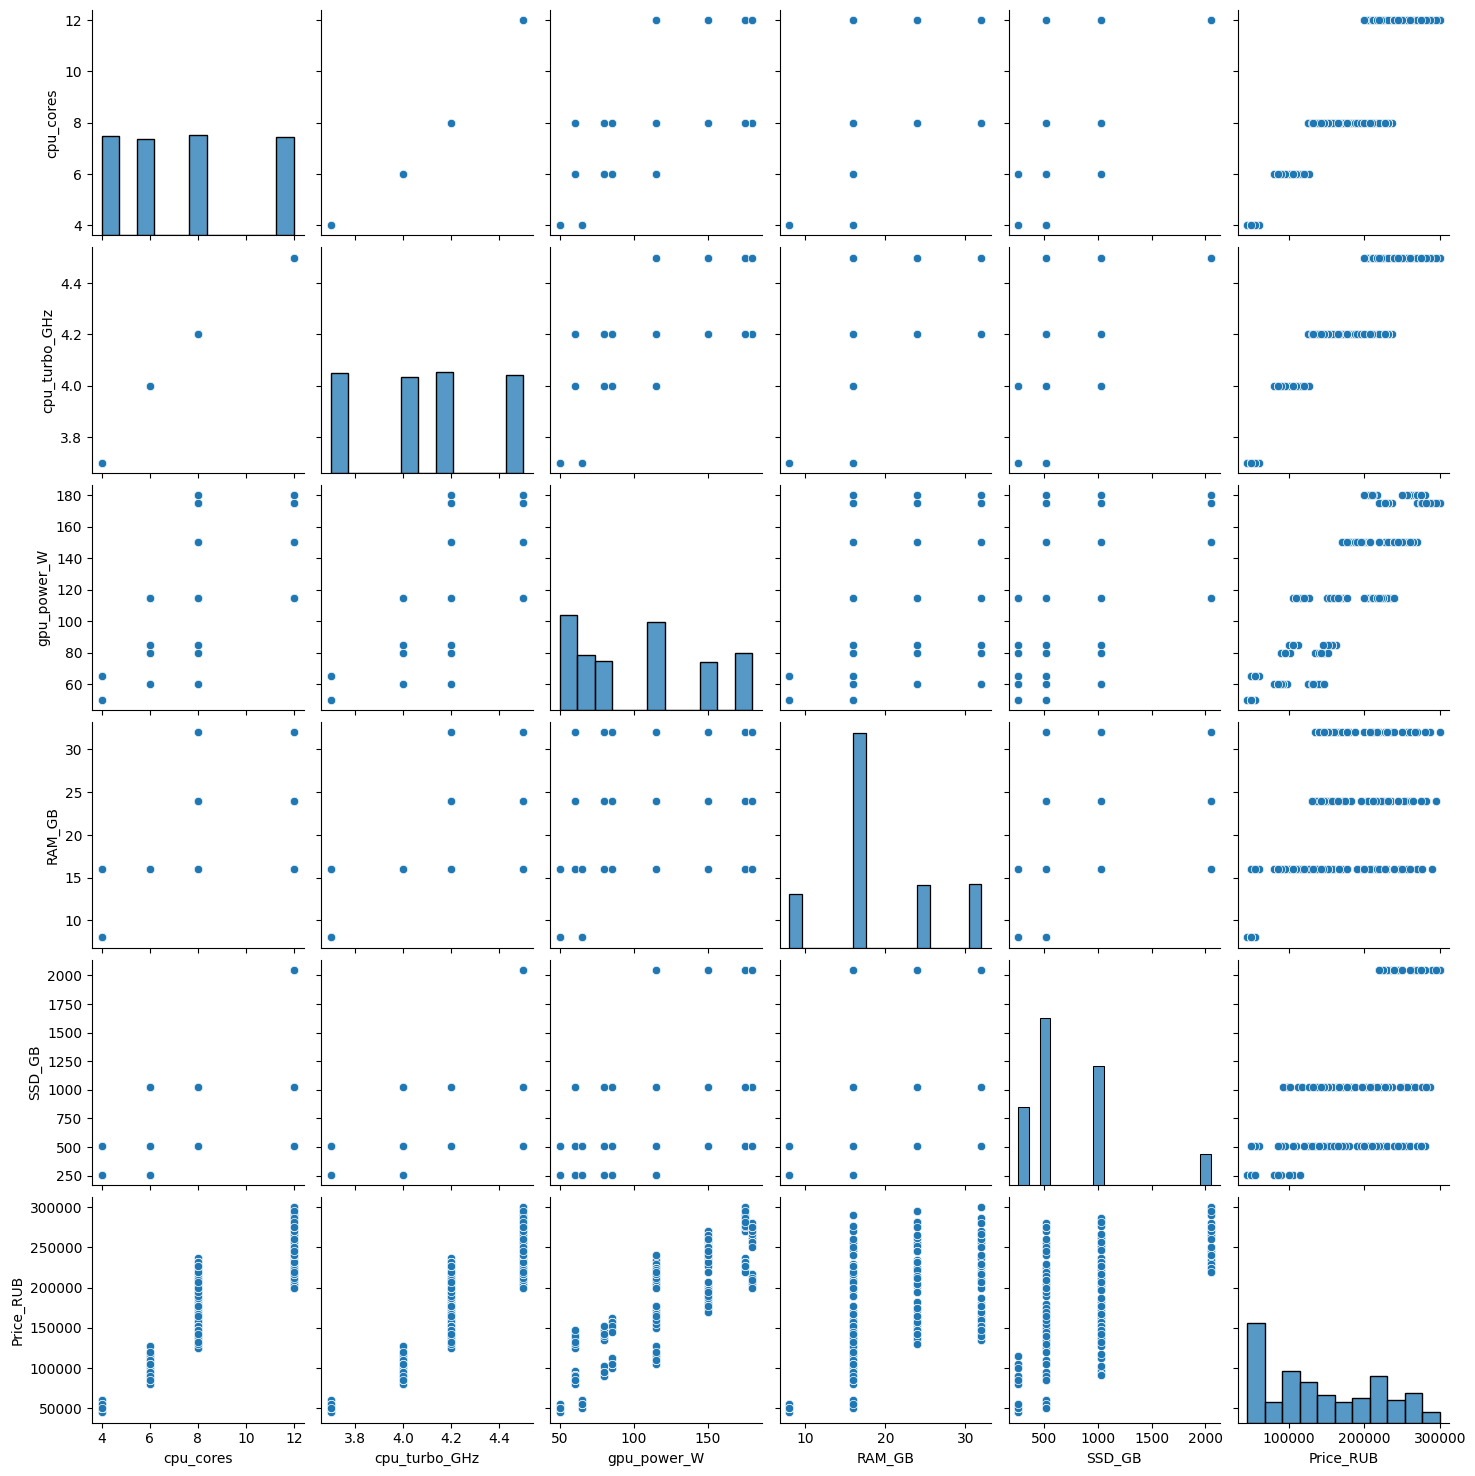

In [ ]:
sns.pairplot(df)
plt.show()

На графиках видно, что цена растёт примерно линейно при росте мощности GPU, более мощные ноутбуки имеют и большее количество ядер, и выше частоты, RAM и SSD почти не влияют на цену (слабая корреляция).

Анализ выбросов

1. Сделаем визуализацию и удаление выбросов с помощью ящиков с усами.

In [ ]:
#Можно вывести все сразу переменные
px.box(df)

Это неинформативно, поэтому лучше рассматривать либо попарно те величины, которые находятся примерно в одном диапазоне значений, либо отдельно.

In [ ]:
px.box(df['gpu_power_W'], title='Ящик с усами с выбросами') #вывод для gpu_power_W

У мощных моделей есть точки, которые выглядят как выбросы (в районе 180 Вт), но для игровых ноутбуков это нормальные значения, поэтому удалять их не нужно.

In [ ]:
px.box(df['cpu_cores'], title='Ящик с усами с выбросами') #вывод для cpu_cores

Выбросов нет.

In [ ]:
px.box(df['cpu_turbo_GHz'], title='Ящик с усами с выбросами') #вывод для cpu_turbo_GHz

Выбросов тоже нет.

In [ ]:
px.box(df['RAM_GB'], title='Ящик с усами с выбросами') #вывод для RAM_GB

Выбросов не наблюдается.

In [ ]:
px.box(df['SSD_GB'], title='Ящик с усами с выбросами') #вывод для SSD_GB

На графике SSD_GB наблюдается выброс в области 2048 Гб. Это редкое значение, так как основное количество моделей ноутбуков оснащено SSD объёмом 256-1024 Гб. Однако для современных ноутбуков 2048 Гб - это норма, поэтому данных выброс имеет естественную природу и не будет удаляться.




In [ ]:
px.box(df['Price_RUB'], title='Ящик с усами с выбросами') #вывод для Price_RUB

По ценам выбросов нет.

2. Визуализация и удаление выбросов с помощью точечных диаграмм.

In [ ]:
px.scatter(df, x='Price_RUB', y='SSD_GB')

Проверили ещё раз данные с SSD_GB. На блокспоте 2048 Гб выделялось как выброс, но модели с 2048 Гб встречаются в ценовом диапазоне 200-300 тыс. рублей. Это достаточно дорого, а значит, что эта точка не является ошибкой, это норма.

3. Метод Z-оценки для выявления выбросов

Z-оценка выбросов — это статистическая мера, которая показывает, насколько далеко (в стандартных отклонениях) находится каждое значение от среднего значения набора данных.

Интерпретация z-оценки:

    1. 0 показывает, что точка данных находится точно в среднем значении.
    2. положительное значение показывает, что точка данных выше среднего значения.
    3. отрицательное значение показывает, что точка данных ниже среднего значения.

In [ ]:
z = np.abs(stats.zscore(df))
print(z)

[[0.17018312 0.34407682 0.27891133 0.72154793 0.60853002 0.24814228]
 [1.52344645 1.37215344 1.64754687 0.72154793 0.60853002 1.8344156 ]
 [0.50644855 0.34130759 0.40540644 0.38252077 0.46918862 0.50533754]
 ...
 [0.50644855 0.34130759 0.40540644 0.38252077 0.46918862 0.50533754]
 [0.17018312 0.34407682 1.07728206 1.82561662 0.60853002 0.84299478]
 [1.18308022 1.36938421 1.20377717 1.48658947 0.46918862 1.23237948]]


Все данные находятся примерно в диапазоне от 0 до 3 - стандартное отклонение с использованием подхода на основе распределение Гаусса.

In [ ]:
threshold_z = 3

outlier_indices = np.where(z > threshold_z)[0]
df_2 = df.drop(outlier_indices)

In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cpu_cores      990 non-null    int64  
 1   cpu_turbo_GHz  990 non-null    float64
 2   gpu_power_W    990 non-null    int64  
 3   RAM_GB         990 non-null    int64  
 4   SSD_GB         990 non-null    int64  
 5   Price_RUB      990 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 46.5 KB


Количество наблюдений никак не сократилось. Значит, с данными всё хорошо, выбросов нет.

4. Метод межквартильного размаха (IQR)

Границы усов определяются, как Q1 - 1.5×IQR и Q3 + 1.5×IQR, где IQR - межквартильный размах (Q3-Q1). Следовательно, то, что выше или ниже этих границ, является аномальным значением.

In [ ]:
all_outliers_indices = set()

for column in df:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    upper_array = np.where(df[column] >= upper)[0]
    lower_array = np.where(df[column] <= lower)[0]

    all_outliers_indices.update(upper_array)
    all_outliers_indices.update(lower_array)


df_3 = df.drop(index=list(all_outliers_indices))

In [ ]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 913 entries, 0 to 989
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cpu_cores      913 non-null    int64  
 1   cpu_turbo_GHz  913 non-null    float64
 2   gpu_power_W    913 non-null    int64  
 3   RAM_GB         913 non-null    int64  
 4   SSD_GB         913 non-null    int64  
 5   Price_RUB      913 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 49.9 KB


Количество наблюдений сократилось до 913. Будем работать с этим датафреймом df_3.

# Подготовка данных к моделированию

In [ ]:
#Масштабируем признаки
scaler_standard = StandardScaler() #преобразует значения к стандартному нормальному распределению (mean=0, std=1)
df_3_std = scaler_standard.fit_transform(df_3)

In [ ]:
#Вставляем стандартизированные значения в датафрейм
columns_to_replace = df_3.columns
df_3[columns_to_replace] = df_3_std

In [ ]:
df_3

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
0,0.319820,0.481432,0.378452,0.783206,1.355183,0.403086
1,1.768930,1.557876,1.781133,0.783206,1.355183,2.106215
2,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900
3,-1.129290,-1.312640,-0.790448,-1.451380,-1.247794,-1.186501
4,1.768930,1.557876,0.378452,-0.334087,-0.380135,0.942410
...,...,...,...,...,...,...
985,-0.404735,-0.236197,0.378452,-0.334087,-0.380135,-0.334936
986,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900
987,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900
988,0.319820,0.481432,1.196683,1.900499,1.355183,1.041760


Здесь подготовили данные для моделирования и кластеризации. Исходные данные ноутбуков (количество ядер у процессора, мощность видеокарты, частота процессора, объём оперативной памяти и т.д.) имеют рахные единицы измерения и разные диапазоны значений, поэтому была выполнена стандартизация признаков с помощью StandartScaler() - метод, который приводит все числовые переменные к единому масштабу, где 0 - среднее значение, 1 - стандартное значение.

In [ ]:
# #Масштабируем признаки другим методом
# scaler_standard_2 = MinMaxScaler() #преобразует значения в диапазоне от 0 до 1, можно использовать, когда есть дамми-переменные
# df_3_std_2 = scaler_standard_2.fit_transform(df_3)

In [ ]:
# #Вставляем стандартизированные значения в датафрейм
# columns_to_replace = df_3.columns
# df_3[columns_to_replace] = df_3_std_2

In [ ]:
# df_3

# Определение оптимального количества кластеров и кластерный анализ

1. Метод локтя

Цель метода локтя - определить такое число кластеров k, при котором внутрикластерное расстояние перестаёт резко уменьшаться.

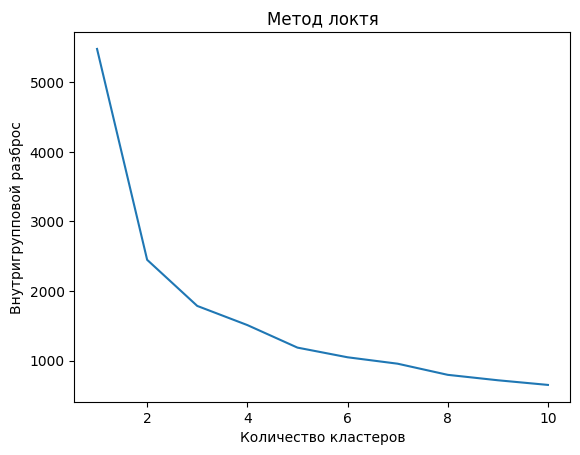

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) #n_clusters - количество кластеров, init - инициализация центроидов, random_state - random_state — это параметр, который контролирует случайность в алгоритмах.
    kmeans.fit(df_3)
    wcss.append(kmeans.inertia_) #inertia_ - это атрибут KMeans, который возвращает значение WCSS
plt.plot(range(1, 11), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Внутригрупповой разброс')
plt.show()

Падение графика становится плавным после k=4. Это означает, что добавление кластеров после 4 не даёт значимого улучшения качества, а только лишь будет усложнять модель.

Внутренняя вариативность (WCSS) резко уменьшается при увеличении числа кластеров до 3. Начиная с k = 4 прирост качества кластеризации минимален, поэтому оставим k = 3.

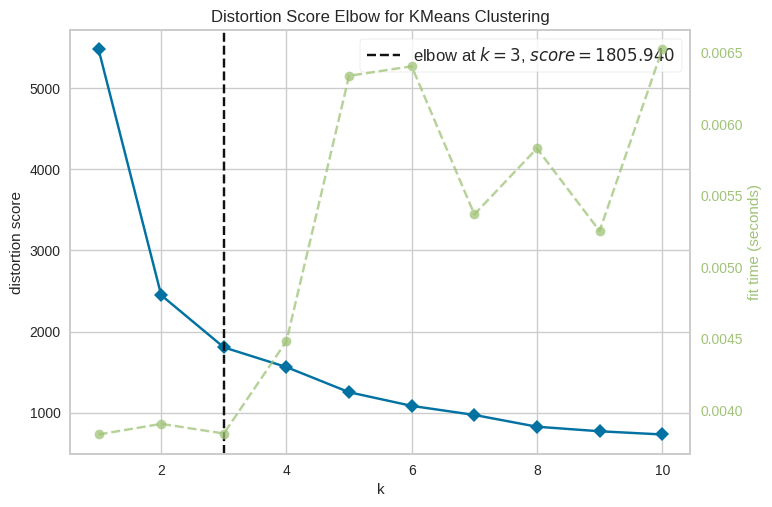

In [ ]:
#Построение метода локтя с учетом скорости обучения модели
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,11))
visualizer.fit(df_3)
visualizer.show();

Этот метод локтя автоматически определил k = 3.

Метод Силуэта. Он определяет, насколько хорошо каждый объект вписывается в свой кластер. Оценка "силуэта" находится в диапазоне [-1, 1].

Оценка силуэта, равная 1, означает, что кластеры очень плотные и хорошо разделены. Оценка 0 означает, что кластеры перекрываются. Оценка менее 0 означает, что данные, относящиеся к кластерам, могут быть неверными.

In [ ]:
#цикл для метода Силуэта
for n_clusters in range(2, 11):
    km = KMeans(n_clusters=n_clusters, random_state=42)
    labels = km.fit_predict(df_3)
    score = silhouette_score(df_3, labels, metric='euclidean')
    print(f'Количество кластеров: {n_clusters}. Метод Силуэта: {score:.3f}')

Количество кластеров: 2. Метод Силуэта: 0.464
Количество кластеров: 3. Метод Силуэта: 0.384
Количество кластеров: 4. Метод Силуэта: 0.363
Количество кластеров: 5. Метод Силуэта: 0.413
Количество кластеров: 6. Метод Силуэта: 0.408
Количество кластеров: 7. Метод Силуэта: 0.420
Количество кластеров: 8. Метод Силуэта: 0.449
Количество кластеров: 9. Метод Силуэта: 0.449
Количество кластеров: 10. Метод Силуэта: 0.455


Максимум достигается при k = 2, но это показывает лишь качество разбиения, а не смысл сегментов.
Если взять k = 2, то, грубо говоря, классы ноутбуков можно поделить лишь на 2, это не совсем хорошо, хоть и граница будет чёткой.

**Дендрограмма**

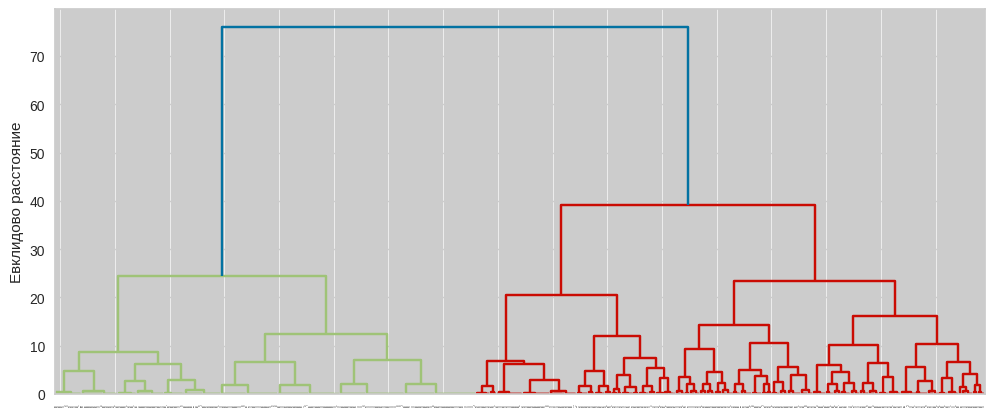

In [ ]:
#Построение дендрограммы
plt.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(df_3, method = 'ward'))
plt.ylabel('Евклидово расстояние')
plt.xticks(fontsize=0.5)
plt.show()

На дендрограмме видно крупные ветви: зелёная, красная и синяя. Следовательно, дендрограмма рекомендует выбрать 3 кластера.

Метод k-средних

Гиперпараметры KMeans

class sklearn.cluster.KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

n_clusters - количество кластеров

init - способ иницализации центроидов (k-means++ - умная, random - случайная)

n_init - количество запусков с разными начальними центроидами

max_iter - максимальное число итераций

tol - допуск сходимости

verbose - уровень детализации вывода

random_state - гиперпараметр, сохраняющий неизменность выборки

copy_x - создание копии данных перед началом вычислений

algorithm - алгоритм оптимизации (lloyd - классический K-means, elkan - более быстрый, но для данных с четкими кластерами)

In [ ]:
kmeans_1 = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42) #кластерный анализ
y_kmeans_1 = kmeans_1.fit_predict(df_3) #сохранение кластеров
df_3['Cluster2'] = y_kmeans_1 #добавление столбца с кластерами в датафрейм

In [ ]:
df_3

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB,Cluster2
0,0.319820,0.481432,0.378452,0.783206,1.355183,0.403086,1
1,1.768930,1.557876,1.781133,0.783206,1.355183,2.106215,1
2,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0
3,-1.129290,-1.312640,-0.790448,-1.451380,-1.247794,-1.186501,0
4,1.768930,1.557876,0.378452,-0.334087,-0.380135,0.942410,1
...,...,...,...,...,...,...,...
985,-0.404735,-0.236197,0.378452,-0.334087,-0.380135,-0.334936,0
986,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0
987,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0
988,0.319820,0.481432,1.196683,1.900499,1.355183,1.041760,1


Это самое простое разбиение на 2 группы. Слишком всё просто.
Кластер 0 имеет меньшие значения признаков, имеет низкие значения для CPU, GPU, RAM, SSD, Price
Кластер 1 имеет высокие значения признаков.

In [ ]:
kmeans_2 = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42) #кластерный анализ
y_kmeans_2 = kmeans_2.fit_predict(df_3) #сохранение кластеров
df_3['Cluster5'] = y_kmeans_2 #добавление столбца с кластерами в датафрейм

In [ ]:
df_3

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB,Cluster2,Cluster5
0,0.319820,0.481432,0.378452,0.783206,1.355183,0.403086,1,3
1,1.768930,1.557876,1.781133,0.783206,1.355183,2.106215,1,1
2,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0,2
3,-1.129290,-1.312640,-0.790448,-1.451380,-1.247794,-1.186501,0,0
4,1.768930,1.557876,0.378452,-0.334087,-0.380135,0.942410,1,4
...,...,...,...,...,...,...,...,...
985,-0.404735,-0.236197,0.378452,-0.334087,-0.380135,-0.334936,0,2
986,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0,2
987,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0,2
988,0.319820,0.481432,1.196683,1.900499,1.355183,1.041760,1,1


При k = 5 получается более глубокая и сложная сегментация. Для простого покупателя ноутбука это будет лишним.

In [ ]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans_3 = kmeans_3.fit_predict(df_3)

# Добавляем новый столбец в датафрейм
df_3['Cluster3'] = y_kmeans_3
df_3.head()


,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB,Cluster2,Cluster5,Cluster3
0,0.319820,0.481432,0.378452,0.783206,1.355183,0.403086,1,3,2
1,1.768930,1.557876,1.781133,0.783206,1.355183,2.106215,1,1,2
2,-0.404735,-0.236197,-0.322888,-0.334087,-0.380135,-0.405900,0,2,1
3,-1.129290,-1.312640,-0.790448,-1.451380,-1.247794,-1.186501,0,0,0
4,1.768930,1.557876,0.378452,-0.334087,-0.380135,0.942410,1,4,2


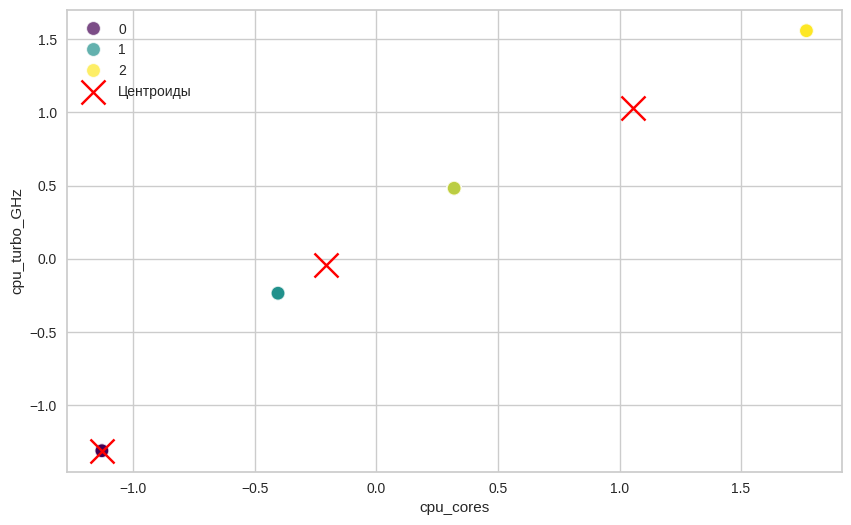

In [ ]:
#Построение графика с центроидами (попарно)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df_3.iloc[:, 0],
    y=df_3.iloc[:, 1],
    hue=df_3['Cluster3'],
    palette='viridis',
    s=100,
    alpha=0.7
)

# Центроиды
plt.scatter(
    kmeans_3.cluster_centers_[:, 0],
    kmeans_3.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='x',
    label='Центроиды'
)

plt.legend()
plt.show()

Имеем такой график при k = 3

# Описание кластеров

In [ ]:
# Кластер 0
cluster3_index_0 = df_3.loc[df_3['Cluster3'] == 0].index.tolist()
cluster3_0 = df.loc[cluster3_index_0]

In [ ]:
cluster3_0.describe().round(2)

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
count,250.0,250.0,250.00,250.00,250.00,250.0
mean,4.0,3.7,58.34,11.71,385.02,52620.0
std,0.0,0.0,7.47,4.00,128.25,4207.9
min,4.0,3.7,50.00,8.00,256.00,45000.0
25%,4.0,3.7,50.00,8.00,256.00,50000.0
50%,4.0,3.7,65.00,8.00,512.00,55000.0
75%,4.0,3.7,65.00,16.00,512.00,55000.0
max,4.0,3.7,65.00,16.00,512.00,60000.0


In [ ]:
# Кластер 1
cluster3_index_1 = df_3.loc[df_3['Cluster3'] == 1].index.tolist()
cluster3_1 = df.loc[cluster3_index_1]

In [ ]:
cluster3_1.describe().round(2)

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
count,330.00,330.00,330.00,330.00,330.00,330.00
mean,6.54,4.05,82.53,17.89,648.53,112630.30
std,0.89,0.09,22.13,4.53,307.32,19856.85
min,6.00,4.00,60.00,16.00,256.00,80000.00
25%,6.00,4.00,60.00,16.00,512.00,95000.00
50%,6.00,4.00,80.00,16.00,512.00,110000.00
75%,8.00,4.20,115.00,16.00,1024.00,130000.00
max,8.00,4.20,115.00,32.00,1024.00,160000.00


In [ ]:
# Кластер 2
cluster3_index_2 = df_3.loc[df_3['Cluster3'] == 2].index.tolist()
cluster3_2 = df.loc[cluster3_index_2]

In [ ]:
cluster3_2.describe().round(2)

,cpu_cores,cpu_turbo_GHz,gpu_power_W,RAM_GB,SSD_GB,Price_RUB
count,333.00,333.00,333.00,333.00,333.00,333.00
mean,10.03,4.35,145.33,23.90,779.53,215174.17
std,2.00,0.15,28.94,6.66,256.13,34620.40
min,8.00,4.20,80.00,16.00,512.00,152000.00
25%,8.00,4.20,115.00,16.00,512.00,195000.00
50%,12.00,4.50,150.00,24.00,1024.00,215000.00
75%,12.00,4.50,175.00,32.00,1024.00,237000.00
max,12.00,4.50,180.00,32.00,1024.00,287000.00


Кластер 0 - бюджетные ноутбуки:
(средние значения)
   - Цена = 52620 рублей
   - SSD = 385.02 Гб (среди таковых будут 256 Гб и 512 Гб)
   - RAM = 11.71 ГБ (приближено к 12 Гб ОЗУ, но среди них есть по 8 и 16 Гб)
   - CPU-ядра = 4
   - Частота CPU в турбобусте = 3.7 ГГц
   - Мощность GPU = 58.34 Вт

Кластер 1 - средний сегмент
   - Цена = 112630.3 рублей
   - SSD = 648.53 Гб (среди таковых много с 512 Гб, но встречаются и с 10124 Гб)
   - RAM = 17.89 ГБ (приближенно к 18 Гб, но среди них 16 и 24 Гб)
   - CPU-ядра = 6.54 (6 и 8 ядер)
   - Частота CPU в турбобусте = 4.05 ГГц
   - Мощность GPU = 82.53 Вт

Кластер 2 - топовые игровые ноутбуки
   - Цена = 215174.17 рублей
   - SSD = 779.53 Гб (от 512 Гб и до 2048 Гб включительно)
   - RAM = 23.9 ГБ (приближенно к 24 Гб, встречаются 16, 24 и 32 Гб)
   - CPU-ядра = 10.03 (8 и 12 ядер)
   - Частота CPU в турбобусте = 4.35 ГГц
   - Мощность GPU = 145.33 Вт